# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datasets/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour


---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [3]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

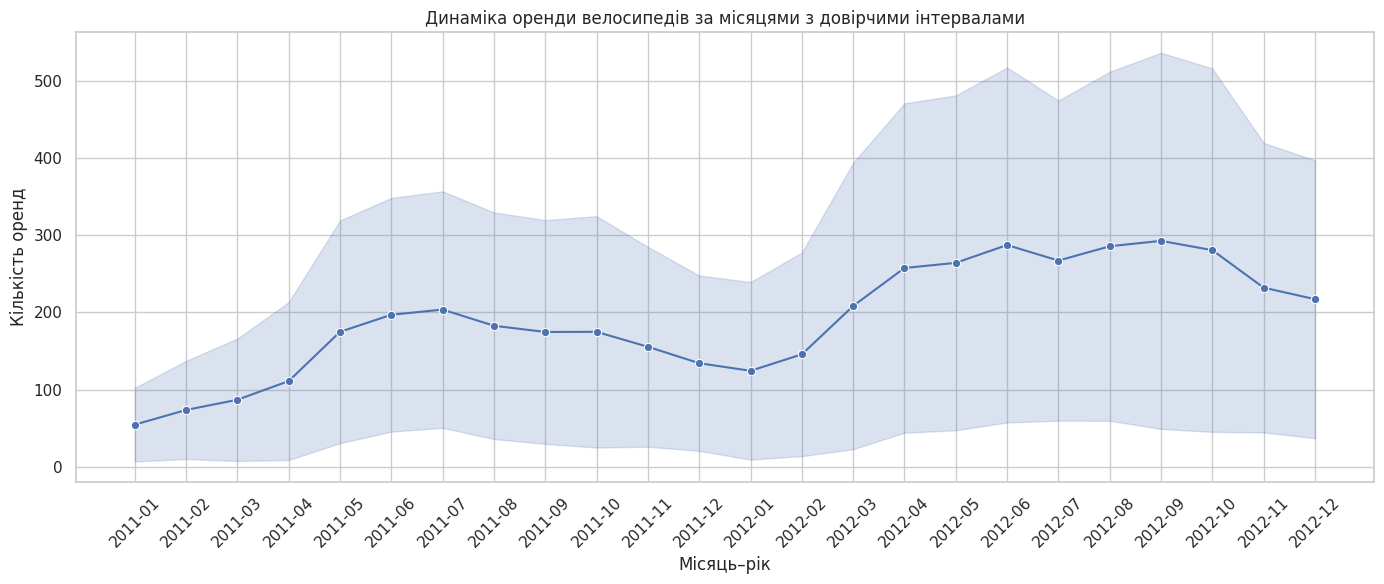

In [6]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=df,
    x='month_year',
    y='count',
    estimator='mean',
    errorbar='sd',
    marker='o'
)

plt.xticks(rotation=45)
plt.title('Динаміка оренди велосипедів за місяцями з довірчими інтервалами')
plt.xlabel('Місяць–рік')
plt.ylabel('Кількість оренд')
plt.tight_layout()
plt.show()

#Висновок:
Найбільша невизначеність спостерігається в літні місяці 2012 року, коли довірчий інтервал є найширшим

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

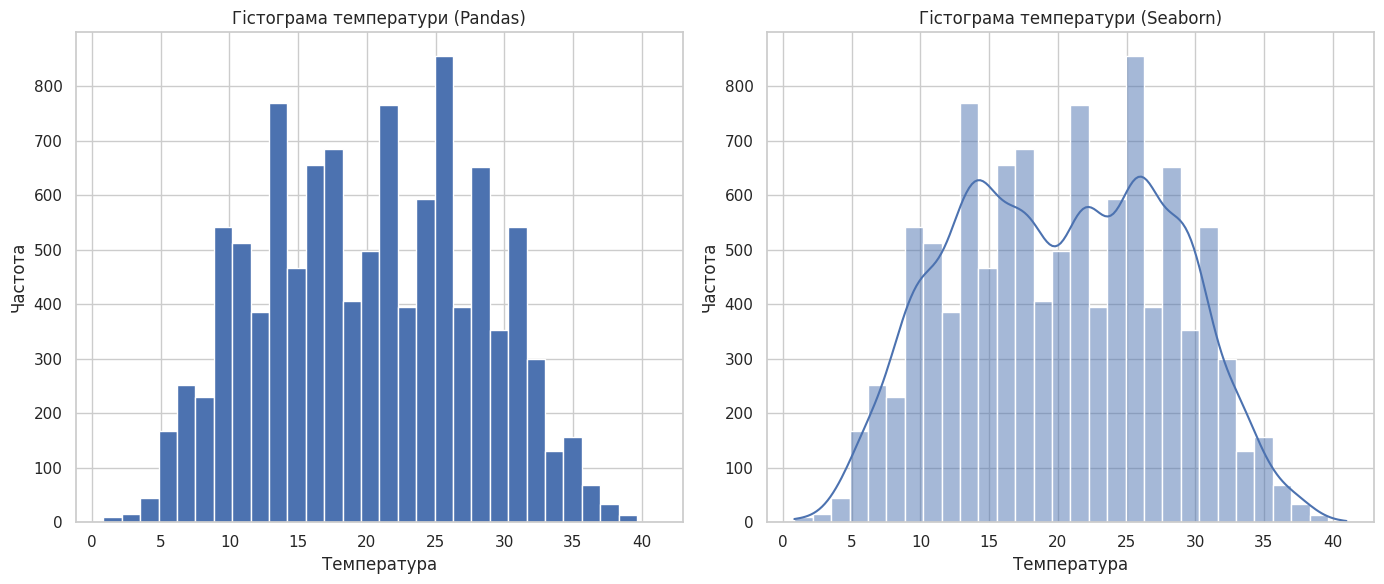

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

bins_number = 30

plt.figure(figsize=(14,6))

#Pandas
plt.subplot(1, 2, 1)

df['temp'].hist(bins=bins_number)

plt.title('Гістограма температури (Pandas)')
plt.xlabel('Температура')
plt.ylabel('Частота')


#Seaborn
plt.subplot(1, 2, 2)

sns.histplot(
    data=df,
    x='temp',
    bins=bins_number,
    kde=True
)

plt.title('Гістограма температури (Seaborn)')
plt.xlabel('Температура')
plt.ylabel('Частота')

plt.tight_layout()
plt.show()

#Висновки:

1. Яка візуальна різниця між Pandas та Seaborn гістограмами? - Гістограма Seaborn виглядає більш сучасною та стилістично оформленою. В Seaborn додатково відображається згладжена крива розподілу (KDE), що дозволяє краще побачити форму розподілу даних. Гістограма Pandas є більш базовою та не містить додаткових елементів візуалізації.

2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами? - Це KDE (Kernel Density Estimation), або оцінка щільності розподілу. Вона показує згладжену форму розподілу температури та допомагає краще зрозуміти, як дані розподіляються без прив’язки до конкретних бінів гістограми.

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

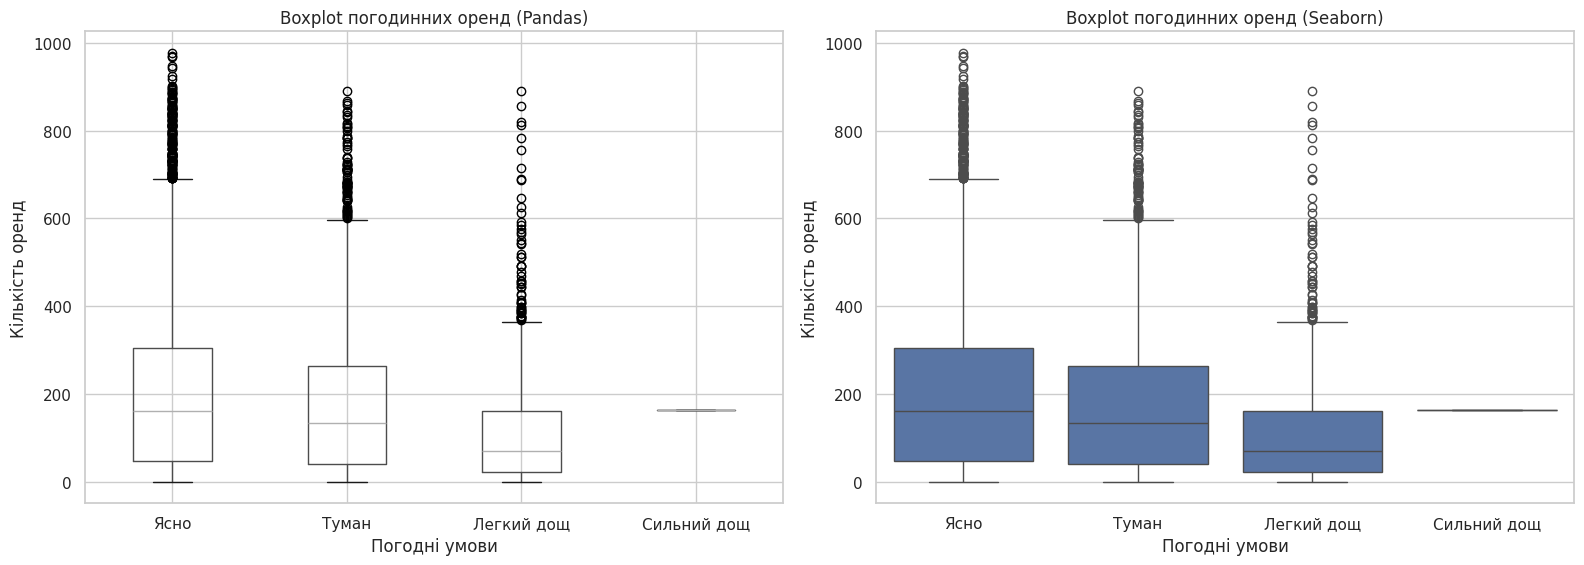

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

order = ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']

df['weather_label'] = pd.Categorical(df['weather_label'], categories=order, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Pandas
df.boxplot(column='count', by='weather_label', ax=axes[0])
axes[0].set_title('Boxplot погодинних оренд (Pandas)')
axes[0].set_xlabel('Погодні умови')
axes[0].set_ylabel('Кількість оренд')

fig.suptitle('')

#Seaborn
sns.boxplot(
    data=df,
    x='weather_label',
    y='count',
    order=order,
    ax=axes[1]
)
axes[1].set_title('Boxplot погодинних оренд (Seaborn)')
axes[1].set_xlabel('Погодні умови')
axes[1].set_ylabel('Кількість оренд')

plt.tight_layout()
plt.show()

#Висновки:

Яка візуальна різниця між Pandas та Seaborn бокс-плотами? - Seaborn має більш привабливий стиль та кращу візуалізацію, тоді як Pandas створює базовий варіант графіка.

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


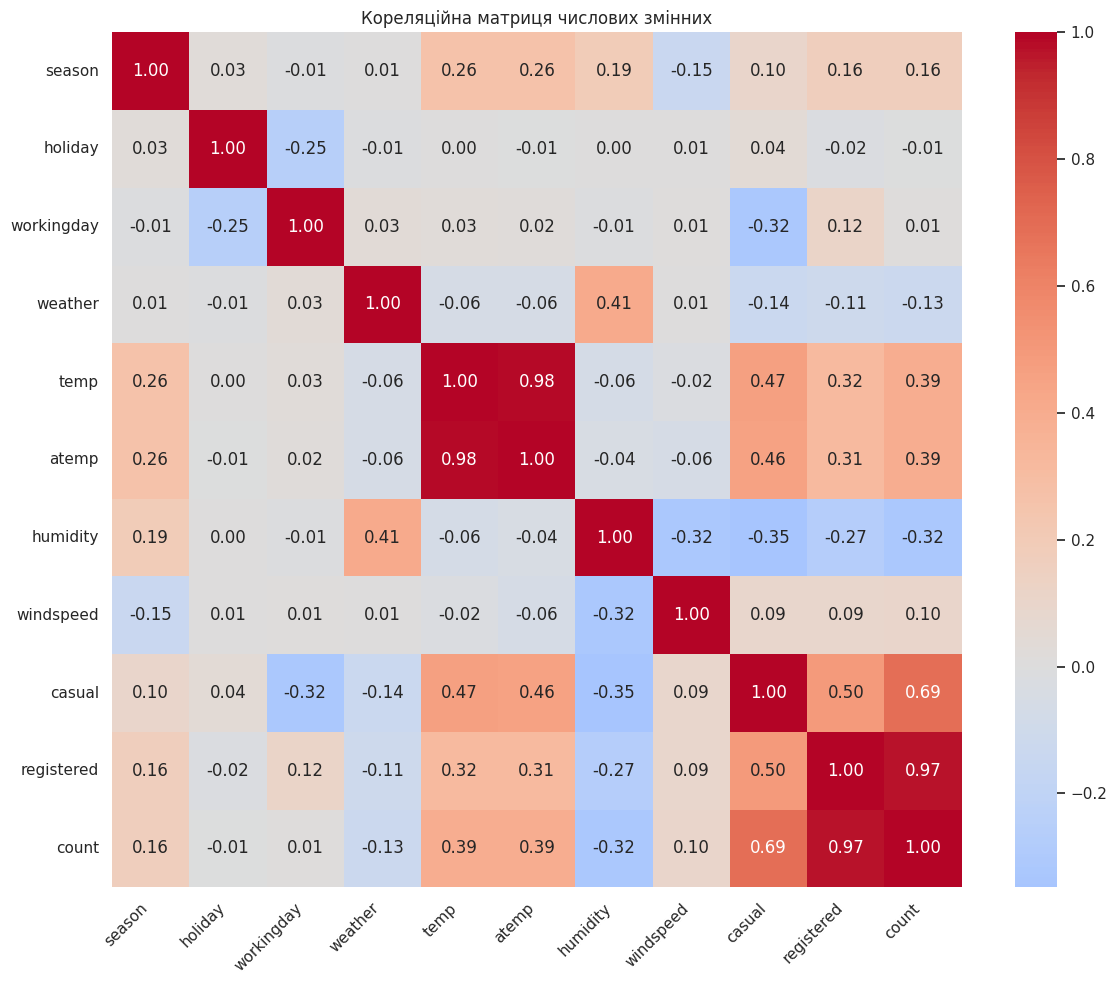

In [15]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title('Кореляційна матриця числових змінних')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#Висновки:

1. . Які змінні найсильніше корелюють з загальною кількістю оренди (count)? - Найсильніша позитивна кореляція з загальною кількістю оренд (count) спостерігається для змінної registered (0.97) та casual (0.69). Це логічно, оскільки count є сумою зареєстрованих і випадкових користувачів

2. Яка кореляція між temp та atemp? Чому? - Між temp та atemp спостерігається дуже висока позитивна кореляція (0.98), оскільки atemp є скоригованим показником фактичної температури та відображає її відчутне значення. Обидві змінні описують практично одну й ту ж характеристику.

3. Які змінні мають негативну кореляцію? - Негативну кореляцію з count мають humidity (-0.32) та weather (-0.13), що означає зменшення кількості оренд при підвищенні вологості або погіршенні погодних умов. Слабку негативну кореляцію також має windspeed (-0.10).

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


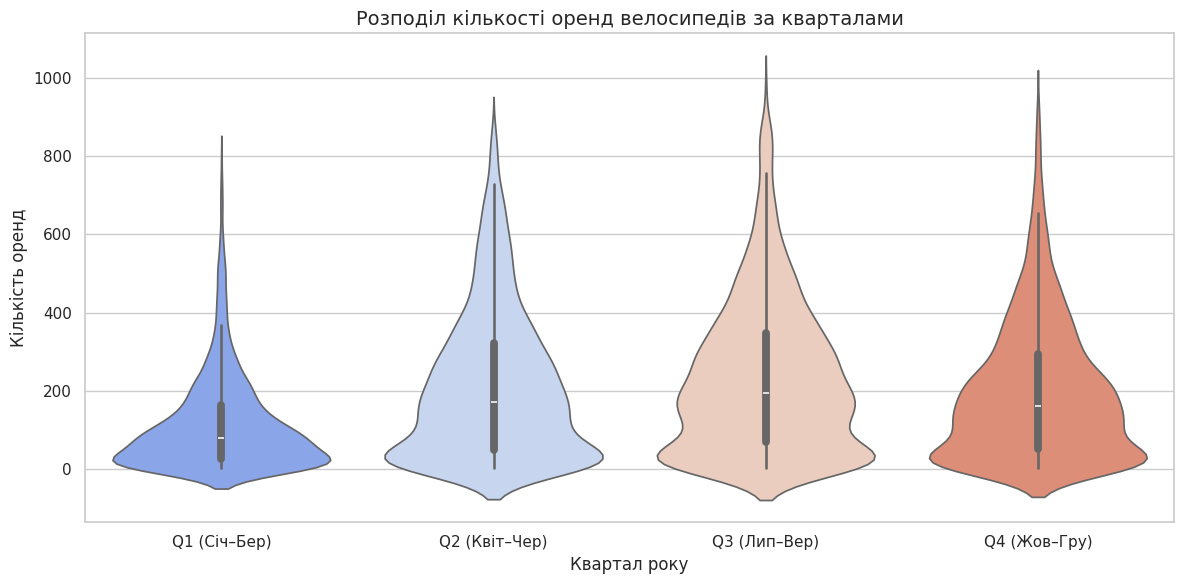

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

season_labels = {
    1: 'Q1 (Січ–Бер)',
    2: 'Q2 (Квіт–Чер)',
    3: 'Q3 (Лип–Вер)',
    4: 'Q4 (Жов–Гру)'
}

df['season_label'] = df['season'].map(season_labels)

order = [
    'Q1 (Січ–Бер)',
    'Q2 (Квіт–Чер)',
    'Q3 (Лип–Вер)',
    'Q4 (Жов–Гру)'
]

plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df,
    x='season_label',
    y='count',
    hue='season_label',
    order=order,
    inner='box',
    palette='coolwarm',
    legend=False
)

plt.title('Розподіл кількості оренд велосипедів за кварталами', fontsize=14)
plt.xlabel('Квартал року', fontsize=12)
plt.ylabel('Кількість оренд', fontsize=12)

plt.tight_layout()
plt.show()

#Висновки:

1. Що показує "товщина" violin plot? - Товщина violin plot відображає щільність розподілу даних. Чим ширша частина графіка на певному рівні значень, тим більше спостережень зосереджено в цьому діапазоні кількості оренд.

2. В якому кварталі найбільша варіабельність оренди? - Найбільша варіабельність оренди спостерігається у Q3 (Лип–Вер), оскільки розподіл має найбільший діапазон значень та ширший розмах. У Q1 варіабельність є найменшою.

3. Яка перевага violin plot над звичайним box plot? - Перевага violin plot полягає в тому, що він показує повну форму розподілу та щільність даних, тоді як box plot відображає лише медіану та квартилі. Violin plot дозволяє побачити асиметрію та концентрацію значень у різних діапазонах.

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

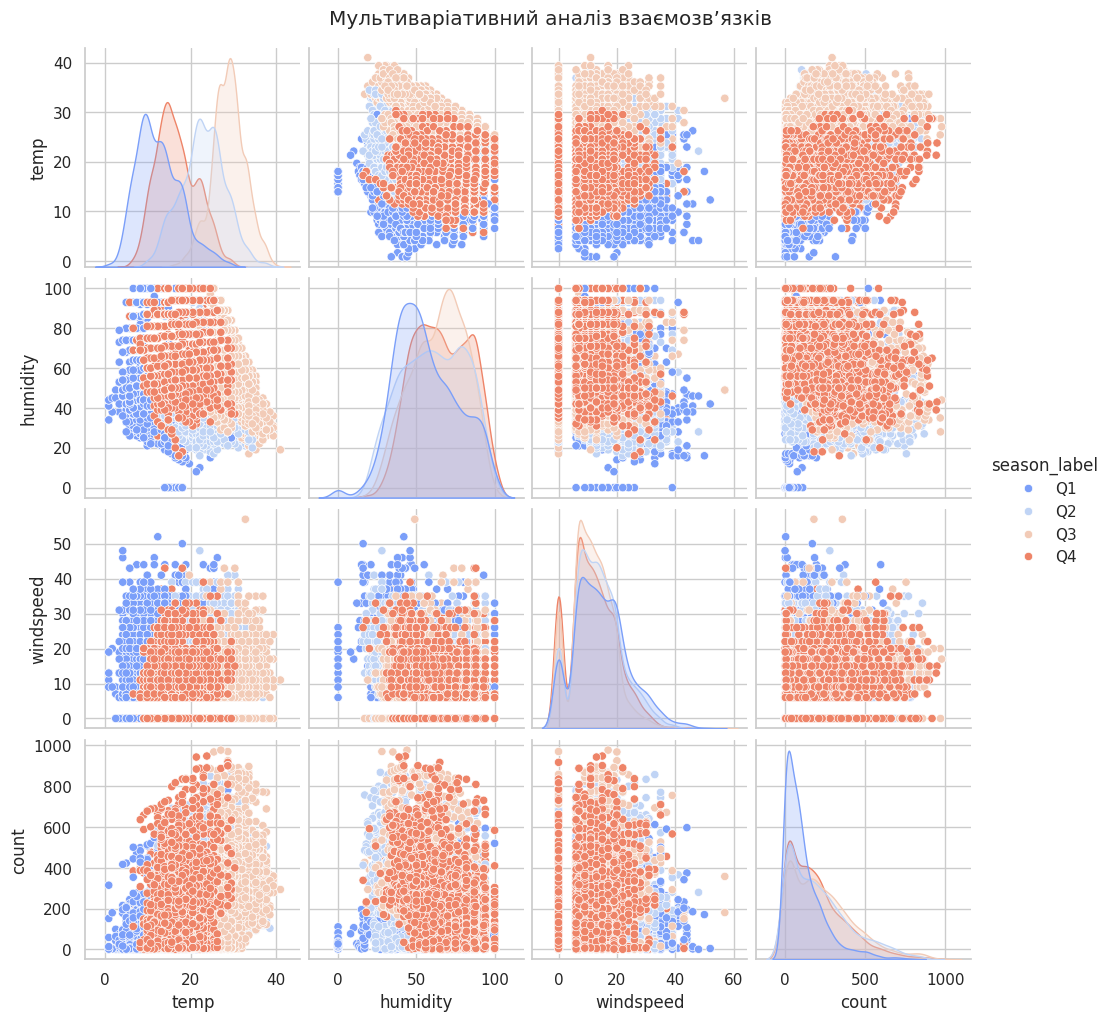

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

season_labels = {
    1: 'Q1',
    2: 'Q2',
    3: 'Q3',
    4: 'Q4'
}

df['season_label'] = df['season'].map(season_labels)

pair = sns.pairplot(
    df[['temp', 'humidity', 'windspeed', 'count', 'season_label']],
    hue='season_label',
    diag_kind='kde',
    palette='coolwarm'
)

plt.suptitle('Мультиваріативний аналіз взаємозв’язків', y=1.02)
plt.show()

#Висновки:

1. Між якими змінними спостерігається найсильніший лінійний зв'язок? - Найсильніший лінійний зв’язок спостерігається між temp та count - зі зростанням температури кількість оренд збільшується.

2. Яка характеристика найбільше відрізняється між кварталами? - Найбільше між кварталами відрізняється температура (temp), оскільки розподіли кварталів чітко розділяються саме за цим показником. Інші змінні мають значно більший перетин між кварталами.




## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

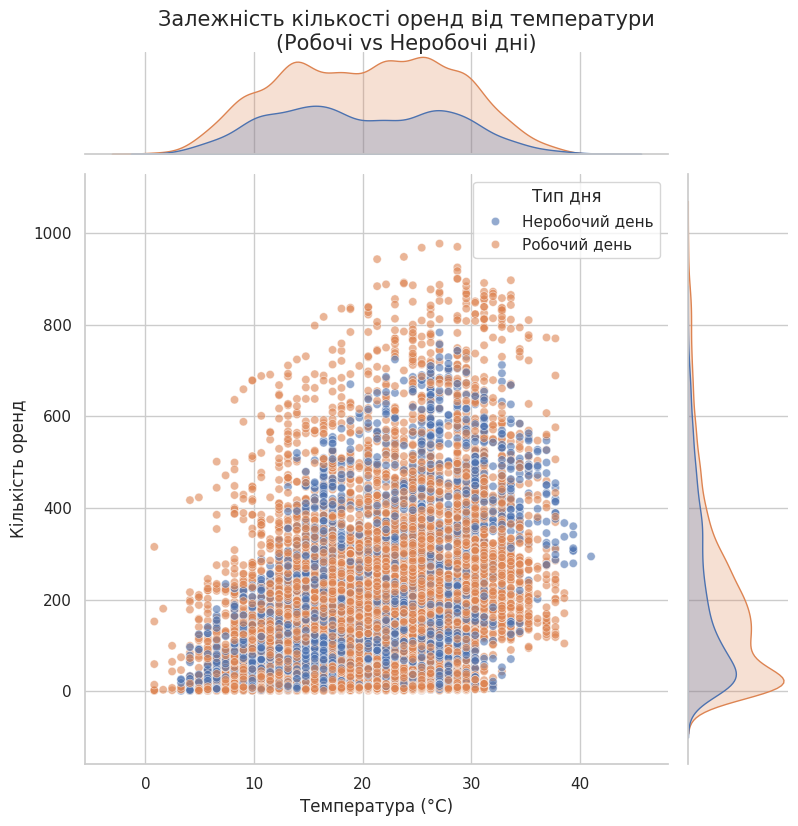

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

df["Тип дня"] = df["workingday"].map({
    0: "Неробочий день",
    1: "Робочий день"
})

g = sns.jointplot(
    data=df,
    x="temp",
    y="count",
    hue="Тип дня",
    kind="scatter",
    palette=["#4C72B0", "#DD8452"],
    height=8,
    alpha=0.6
)

g.fig.suptitle(
    "Залежність кількості оренд від температури\n(Робочі vs Неробочі дні)",
    y=1.03,
    fontsize=15
)

g.ax_joint.set_xlabel("Температура (°C)", fontsize=12)
g.ax_joint.set_ylabel("Кількість оренд", fontsize=12)

plt.show()

#Висновки:

1. Що показують графіки по краях? - Графіки по краях показують розподіл температури та кількості оренд окремо для робочих і неробочих днів. Вони дозволяють побачити, як змінюється частота значень та чи є зсув розподілу між категоріями.

2. Чи є різниця у поведінці користувачів у робочий і неробочий день? - Так, різниця спостерігається. У робочі дні кількість оренд в середньому вища, ніж у неробочі. Залежність між температурою та кількістю оренд є позитивною в обох випадках, однак у робочі дні попит більш інтенсивний і варіабельний.